<a href="https://colab.research.google.com/github/changyunyeong/MachineLearning_2026_01/blob/main/ML%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_6%E1%84%8C%E1%85%A1%E1%86%BC_Classification(3)(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Linear SVM과 Margin
## SVM(Support Vector Machine)의 기본 목적은 데이터를 분류하는 최적의 선형 초평면(Decision boundary)을 찾는 것

###-> 이때 가장 좋은 초평면은 두 클래스 사이의 마진(Margin)을 최대화하는 것

Margin은 수식으로 $\frac{2}{||w||}$ 로 표현되며, 이를 최대화하는 것은 결과적으로 아래의 목적 함수를 최소화하는 것과 같음

**Objective:** $min \frac{||w||^2}{2}$

**Constraints:** $y_i(w^Tx_i + b) \ge 1$ for $i=1,...,n$

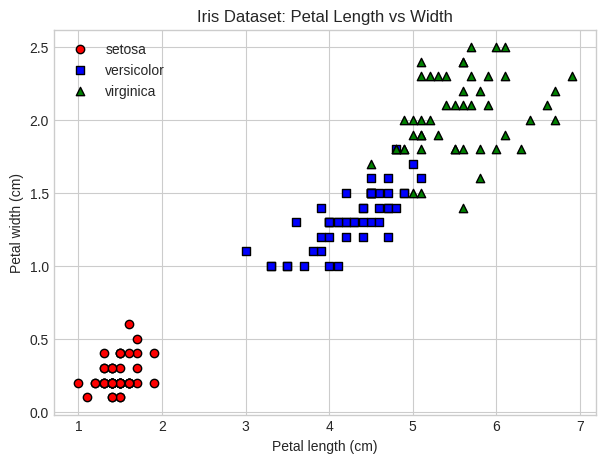

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

plt.style.use('seaborn-v0_8-whitegrid')

# Iris 데이터셋 로드
iris = datasets.load_iris()
# 2차원 시각화를 위해 꽃잎 길이(Petal Length)와 너비(Petal Width) 두 개의 특성만 사용
X = iris.data[:, 2:]
y = iris.target
target_names = iris.target_names

plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

for i, color, marker, target_name in zip(range(3), colors, markers, target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, marker=marker,
                edgecolors='k', label=target_name)

plt.title("Iris Dataset: Petal Length vs Width")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc='upper left')
plt.show()

# 2. (Non-separable) Soft-margin SVM
##실제 데이터는 선형으로 완벽하게 분리되지 않는 경우가 많음

##이때 슬랙 변수(Slack variables) $\xi_i \ge 0$를 도입하여 약간의 오차를 허용하는 Soft-margin을 사용

* **Objective:** $min \frac{1}{2}w^Tw + C\sum_i \xi_i$
* **Constraints:** $y_i(w^Tx_i + b) \ge 1 - \xi_i$, $\xi_i \ge 0$

-> 여기서 하이퍼파라미터 $C$는 Trade-off를 결정

$C$가 작으면 규제가 강해져 마진 오류를 많이 허용하고(underfitting), $C$가 크면 오차를 줄이려 함(overfitting)

<Figure size 600x400 with 0 Axes>

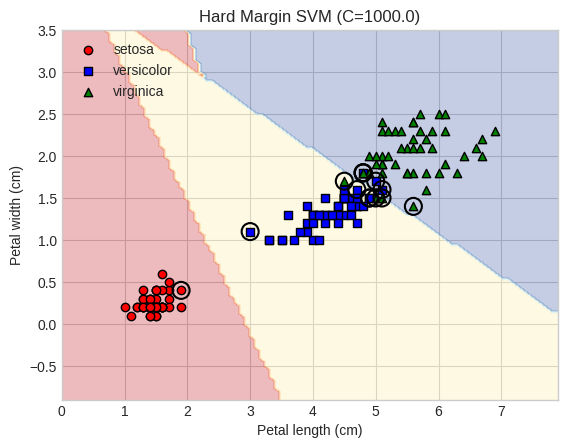

Hard Margin 모델의 서포트 벡터 개수: 14개


In [2]:
# Hard Margin SVM 학습 (C값을 아주 크게 설정)
hard_svm = SVC(kernel='linear', C=1000.0)
hard_svm.fit(X, y)

plt.figure(figsize=(6, 4))
DecisionBoundaryDisplay.from_estimator(hard_svm, X, response_method="predict", cmap=plt.cm.RdYlBu, alpha=0.3)

for i, color, marker in zip(range(3), colors, markers):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, marker=marker, edgecolors='k', label=target_names[i])

# 서포트 벡터 시각화
support_vectors_hard = hard_svm.support_vectors_
plt.scatter(support_vectors_hard[:, 0], support_vectors_hard[:, 1], s=150, linewidth=1.5, facecolors='none', edgecolors='k')

plt.title("Hard Margin SVM (C=1000.0)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc='upper left')
plt.show()

print(f"Hard Margin 모델의 서포트 벡터 개수: {len(support_vectors_hard)}개")

<Figure size 600x400 with 0 Axes>

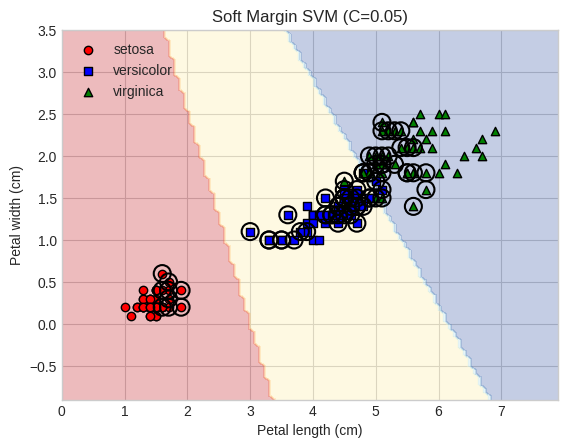

Soft Margin 모델의 서포트 벡터 개수: 78개


In [4]:
# Soft Margin SVM 학습 (C값을 작게 설정)
soft_svm = SVC(kernel='linear', C=0.05)
soft_svm.fit(X, y)

plt.figure(figsize=(6, 4))
DecisionBoundaryDisplay.from_estimator(soft_svm, X, response_method="predict", cmap=plt.cm.RdYlBu, alpha=0.3)

for i, color, marker in zip(range(3), colors, markers):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, marker=marker, edgecolors='k', label=target_names[i])

# 서포트 벡터 시각화
support_vectors_soft = soft_svm.support_vectors_
plt.scatter(support_vectors_soft[:, 0], support_vectors_soft[:, 1], s=150, linewidth=1.5, facecolors='none', edgecolors='k')

plt.title("Soft Margin SVM (C=0.05)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc='upper left')
plt.show()

print(f"Soft Margin 모델의 서포트 벡터 개수: {len(support_vectors_soft)}개")

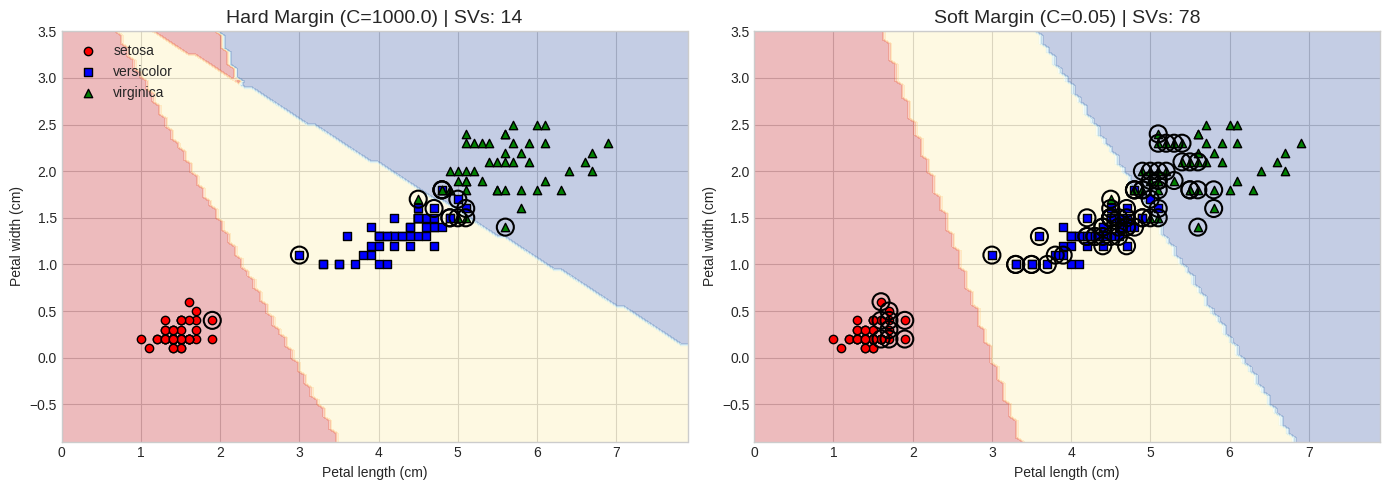

In [5]:
# 시각화를 위한 1x2 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [hard_svm, soft_svm]
titles = [f"Hard Margin (C=1000.0) | SVs: {len(support_vectors_hard)}",
          f"Soft Margin (C=0.05) | SVs: {len(support_vectors_soft)}"]

for ax, model, title in zip(axes, models, titles):
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict",
        cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax
    )

    for i, color, marker in zip(range(3), colors, markers):
        ax.scatter(X[y == i, 0], X[y == i, 1], color=color, marker=marker, edgecolors='k', label=target_names[i])

    # 서포트 벡터 시각화
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=150, linewidth=1.5, facecolors='none', edgecolors='k')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Petal length (cm)")
    ax.set_ylabel("Petal width (cm)")

axes[0].legend(loc='upper left')
plt.tight_layout()
plt.show()

# 3. Kernel SVM과 RBF 커널
##선형으로 분리할 수 없는 데이터를 다루기 위해 커널 트릭(Kernel Trick)을 사용
##원래의 특성 공간을 고차원 공간 $\phi(x)$로 매핑하고, 내적 연산 $x_i^T x_j$를 커널 함수 $k(x_i, x_j)$로 대체

가장 대표적인 **RBF(Radial Basis Function) Kernel**의 수식은 다음과 같음:
* $k(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$

-> $\gamma$ 값이 클수록 개별 데이터 포인트의 영향 범위가 좁아져 결정 경계가 복잡해짐

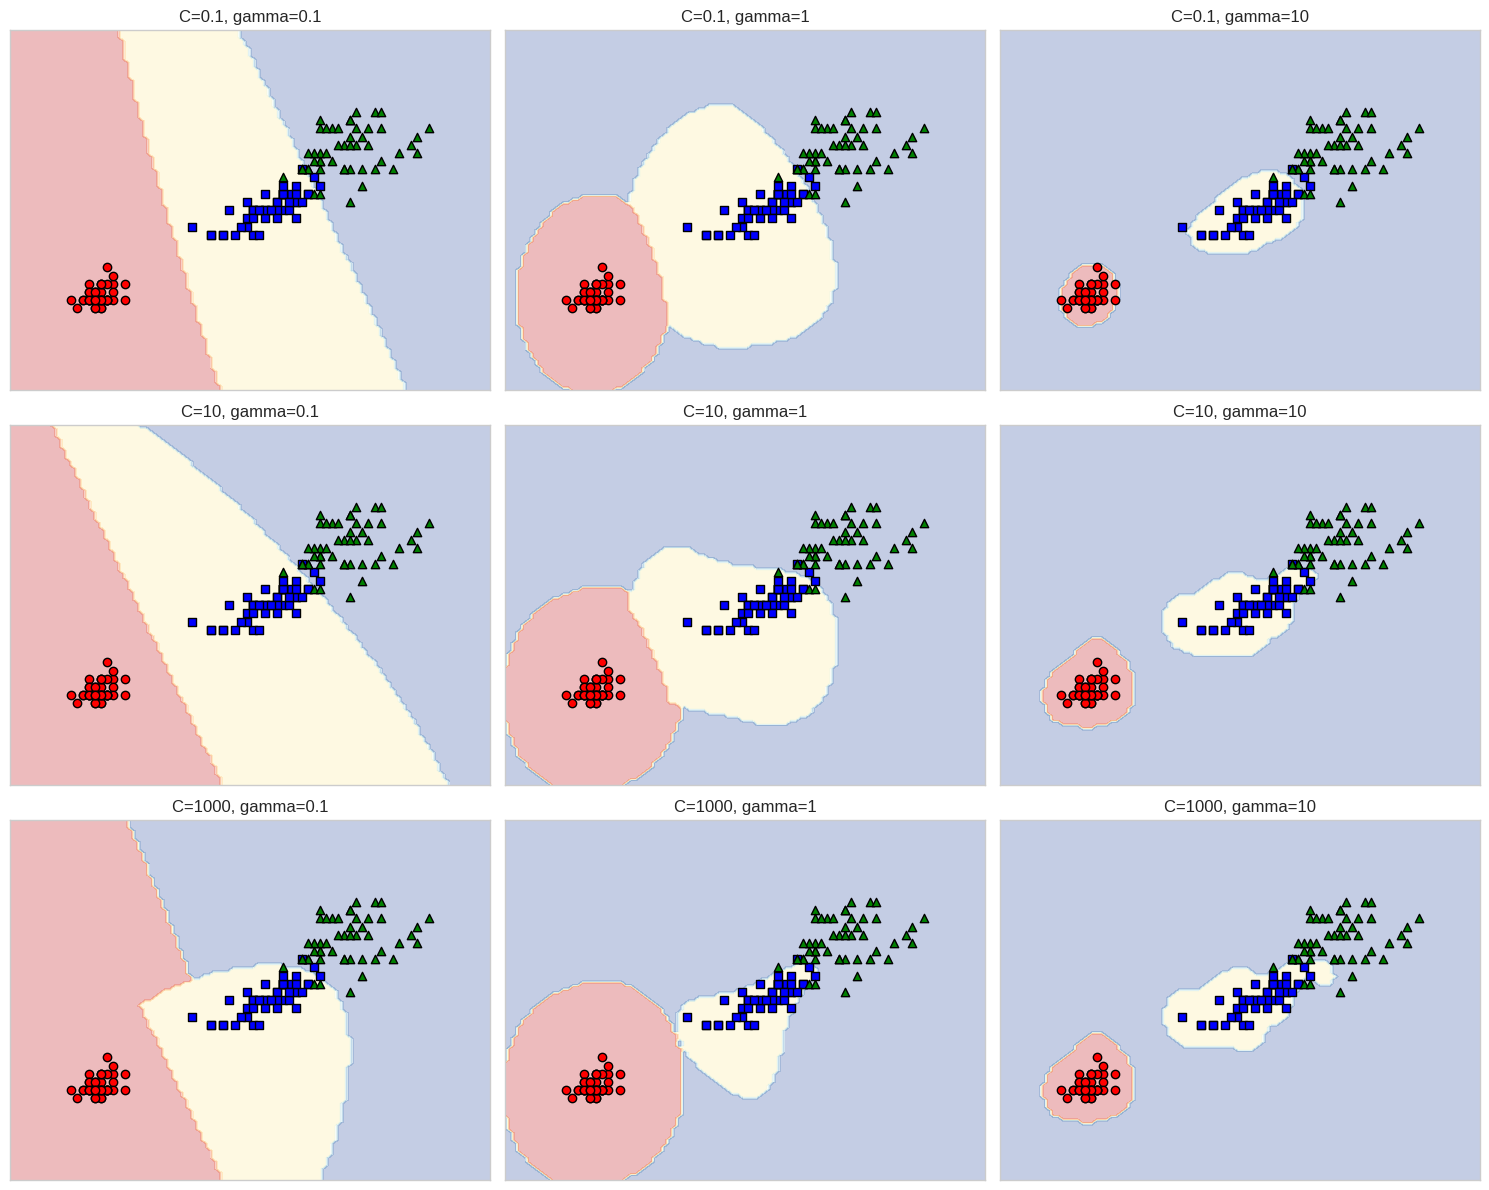

In [6]:
# 비교할 C와 gamma 값 설정
C_values = [0.1, 10, 1000]
gamma_values = [0.1, 1, 10]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):
        # RBF 커널 SVM 학습
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X, y)

        ax = axes[i, j]
        DecisionBoundaryDisplay.from_estimator(
            model, X, response_method="predict",
            cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax
        )

        # 데이터 포인트 스캐터 플롯
        for k, color, marker in zip(range(3), colors, markers):
            ax.scatter(X[y == k, 0], X[y == k, 1], color=color, marker=marker, edgecolors='k')

        ax.set_title(f"C={C}, gamma={gamma}")
        ax.set_xticks(())
        ax.set_yticks(())

plt.tight_layout()
plt.show()

# 4. 실제 데이터 적용: 유방암(Breast Cancer) 진단
## 30개의 수치형 특징(종양의 반경, 질감, 면적 등)을 바탕으로 해당 종양이 악성(Malignant, 암)인지 양성(Benign, 일반 종양)인지 분류하는 이진 분류(Binary Classification) 문제
-> $y_i \in \{-1, +1\}$ 구조

데이터의 분포를 눈으로 확인하기 위해 30개의 특징 중 '종양의 평균 반경'과 '평균 질감' 2개의 특징만 뽑아서 시각화

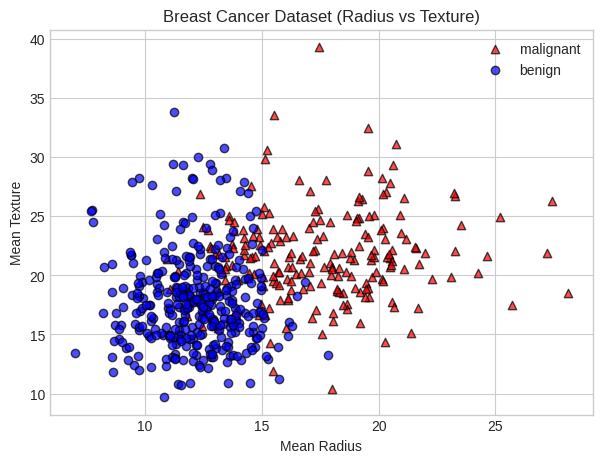

In [7]:
import matplotlib.pyplot as plt
from sklearn import datasets

plt.style.use('seaborn-v0_8-whitegrid')

# 유방암 데이터셋 로드
cancer = datasets.load_breast_cancer()
# 시각화를 위해 첫 2개의 특성(mean radius, mean texture)만 추출
X_2d = cancer.data[:, :2]
y = cancer.target
target_names = cancer.target_names # ['malignant' 'benign']

plt.figure(figsize=(7, 5))
# 악성(0)은 빨간색, 양성(1)은 파란색으로 표시
plt.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], color='red', marker='^', edgecolors='k', label=target_names[0], alpha=0.7)
plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], color='blue', marker='o', edgecolors='k', label=target_names[1], alpha=0.7)

plt.title("Breast Cancer Dataset (Radius vs Texture)")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()
plt.show()

In [8]:
svm_hard_raw = SVC(kernel='linear', C=1000.0).fit(X_raw, y)
svm_soft_raw = SVC(kernel='linear', C=0.01).fit(X_raw, y)
svm_rbf_raw = SVC(kernel='rbf', C=10.0, gamma='scale').fit(X_raw, y)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [svm_hard_raw, svm_soft_raw, svm_rbf_raw]
titles = ["Hard Margin", "Soft Margin", "RBF Kernel"]

for ax, model, title in zip(axes, models, titles):
    DecisionBoundaryDisplay.from_estimator(
        model, X_2d, response_method="predict",
        cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax
    )

    # 데이터 포인트 산점도
    ax.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], color='red', marker='^', edgecolors='k', label=target_names[0], alpha=0.7)
    ax.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], color='blue', marker='o', edgecolors='k', label=target_names[1], alpha=0.7)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Mean Radius")
    ax.set_ylabel("Mean Texture")

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

NameError: name 'X_raw' is not defined

# 5. 전체 특성을 활용한 Kernel SVM 학습과 스케일링
## 그래프를 보면 두 클래스가 선형으로 깔끔하게 나누어지지 않음
## 더 강력한 분류를 위해 30개의 특성을 모두 사용하고, **RBF 커널**을 적용해 비선형(Non-linear) 모델을 학습

또한, SVM은 데이터 점들 간의 '거리'를 계산하여 마진을 구하기 때문에, 각 특성의 단위(Scale)가 다르면 모델이 제대로 작동하지 않음.

-> 따라서 `StandardScaler`를 이용해 모든 특성의 평균을 0, 분산을 1로 맞추는 전처리가 필수적!


---


( 30개의 특성을 가진 고차원 공간의 결정 경계는 2차원 화면에 바로 그릴 수 없음. 따라서 전처리된 30차원 데이터를 PCA(주성분 분석)를 이용해 2개의 핵심 차원으로 압축한 뒤, 마진(Margin)과 서포트 벡터를 눈으로 확인할 수 있음.)

-> **PCA는 다음 수업 내용, 눈으로 확인만 해볼 것**

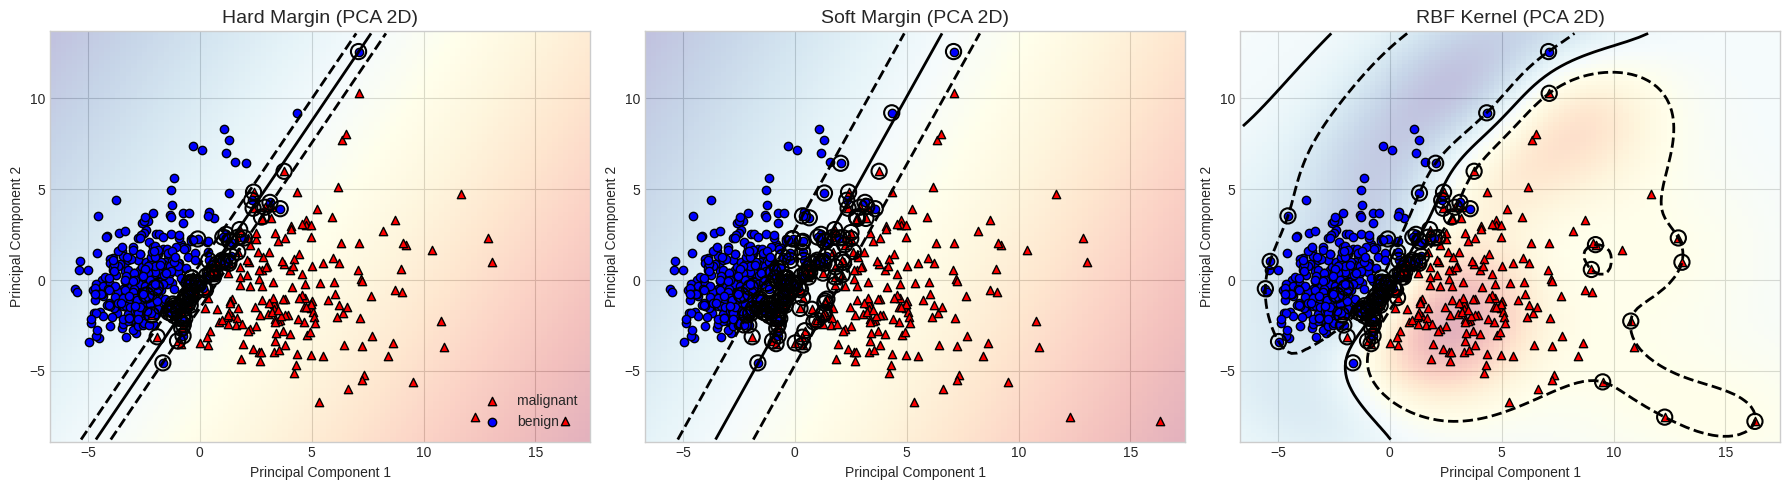

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')

# 데이터 로드 (30개 특성 모두 사용)
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target
target_names = cancer.target_names

# 필수 전처리: StandardScaler 적용 (평균 0, 분산 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 차원 축소 (PCA): 30차원 -> 2차원으로 압축
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3가지 모델 학습 (PCA로 축소된 2D 데이터 사용)
svm_hard = SVC(kernel='linear', C=1000.0).fit(X_pca, y)
svm_soft = SVC(kernel='linear', C=0.01).fit(X_pca, y)
svm_rbf = SVC(kernel='rbf', C=10.0, gamma='scale').fit(X_pca, y)

#마진(Margin) 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [svm_hard, svm_soft, svm_rbf]
titles = ["Hard Margin (PCA 2D)", "Soft Margin (PCA 2D)", "RBF Kernel (PCA 2D)"]

for ax, model, title in zip(axes, models, titles):
    # 거리에 따른 부드러운 그라데이션 배경 (decision_function 사용)
    DecisionBoundaryDisplay.from_estimator(
        model, X_pca, response_method="decision_function",
        cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax, plot_method="pcolormesh"
    )

    # 마진 선 그리기 (-1, 0, 1 위치에 등고선 그림)
    DecisionBoundaryDisplay.from_estimator(
        model, X_pca, response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],           # 마진 경계(-1, 1)와 결정 경계(0)
        colors=['k', 'k', 'k'],
        linestyles=['--', '-', '--'],
        linewidths=2,
        ax=ax
    )

    # 데이터 포인트 산점도
    ax.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', marker='^', edgecolors='k', label=target_names[0])
    ax.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='blue', marker='o', edgecolors='k', label=target_names[1])

    # 서포트 벡터 강조 (동그라미 표시)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, linewidth=1.5, facecolors='none', edgecolors='black')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()

# 실습문제:
## 와인을 3가지 등급으로 분류하는 다중 클래스(Multi-class) 문제


---


### Wine Dataset
* **특성(Features)**: 알코올 농도, 마그네슘, 색상의 강도 등 13개의 수치 데이터

* **타겟(Target)**: 와인 등급 (0, 1, 2)
* **데이터 규모**: 총 178개


---


### 모델 구축 요구사항 (Requirements)
* **데이터 준비**: 와인 데이터의 처음 2개 열(특성)만 사용 (X = wine.data[:, :2])
* **데이터 분할**: train_test_split을 사용하여 학습 데이터와 테스트 데이터를 7:3 비율로 나누기

* **전처리**: SVM은 거리 기반 모델이므로, 반드시 StandardScaler를 사용하여 모든 특성의 스케일을 맞추기

* **모델 구현**: 아래 세 가지 설정의 SVM 모델을 각각 학습
* **Hard Margin**: 오차를 거의 허용하지 않도록 $C$ 값을 100으로 설정
* **Soft Margin**: 오차를 충분히 허용하도록 $C$ 값을 0.01로 설정
* **RBF Kernel**: 적절한 $C$와 gamma 값을 설정
* **평가**: 세 모델의 테스트 정확도(Accuracy)를 출력하고, DecisionBoundaryDisplay를 이용해 2차원 결정 경계를 그리기


---


### **앞서 배운 SVM의 세 가지 접근 방식을 모두 사용하여 어떤 모델이 가장 우수한지 직접 비교**

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. 데이터 로드 및 2차원 특성 추출
wine = load_wine()
X_2d = wine.data[:, :2] # 알코올(Alcohol)과 사과산(Malic acid) 2개 특성만 추출
y = wine.target

In [ ]:
# 2. 데이터 분할
# 코드 작성

In [ ]:
# 3. 전처리 (스케일링)
# 코드 작성

In [ ]:
# 4. 3가지 SVM 모델 정의
# 코드작성
models = {
    "Hard Margin": ,
    "Soft Margin": ,
    "RBF Kernel":
}

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 3 (612131801.py, line 6)

In [ ]:
# 5. 모델 학습
# 코드작성

# 평가 및 결정 경계 시각화


---


위 셀에서 모델 학습을 성공적으로 마쳤다면, 아래 코드를 그대로 실행

세팅한 파라미터가 데이터 분류에 어떤 영향을 미쳤는지 정확도(Accuracy)와 결정 경계 그래프로 확인

-> 단, 변수명이 다를 경우 실행 불가


=== 와인 분류 모델 성능 평가 ===


AttributeError: 'list' object has no attribute 'items'

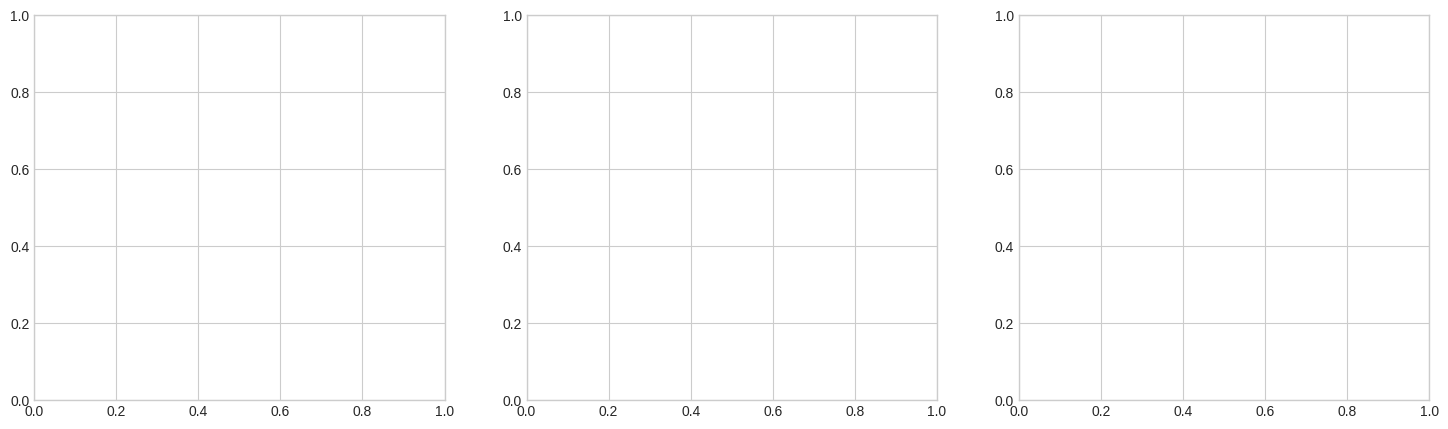

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

print("=== 와인 분류 모델 성능 평가 ===")

# 학습된 모델들을 하나씩 꺼내어 평가 및 시각화 진행
for ax, (name, model) in zip(axes, models.items()):

    # 예측 및 평가
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"✔️ {name:25} Accuracy: {acc * 100:.2f}%")

    # 결정 경계 시각화
    DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="predict",
        cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax
    )

    # 훈련 데이터 산점도
    for i, color, marker, target_name in zip(range(3), colors, markers, wine.target_names):
        ax.scatter(X_train_scaled[y_train == i, 0], X_train_scaled[y_train == i, 1],
                   color=color, marker=marker, edgecolors='k', label=target_name, alpha=0.8)

    ax.set_title(f"{name}\n(Accuracy: {acc * 100:.1f}%)", fontsize=14)
    ax.set_xlabel("Alcohol (Scaled)")
    ax.set_ylabel("Malic Acid (Scaled)")

axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

# 정답 및 해설


---



=== 와인 분류 모델 성능 평가 ===
✔️ Hard Margin (C=100)       Accuracy: 74.07%
✔️ Soft Margin (C=0.01)      Accuracy: 74.07%
✔️ RBF Kernel (Non-linear)   Accuracy: 81.48%


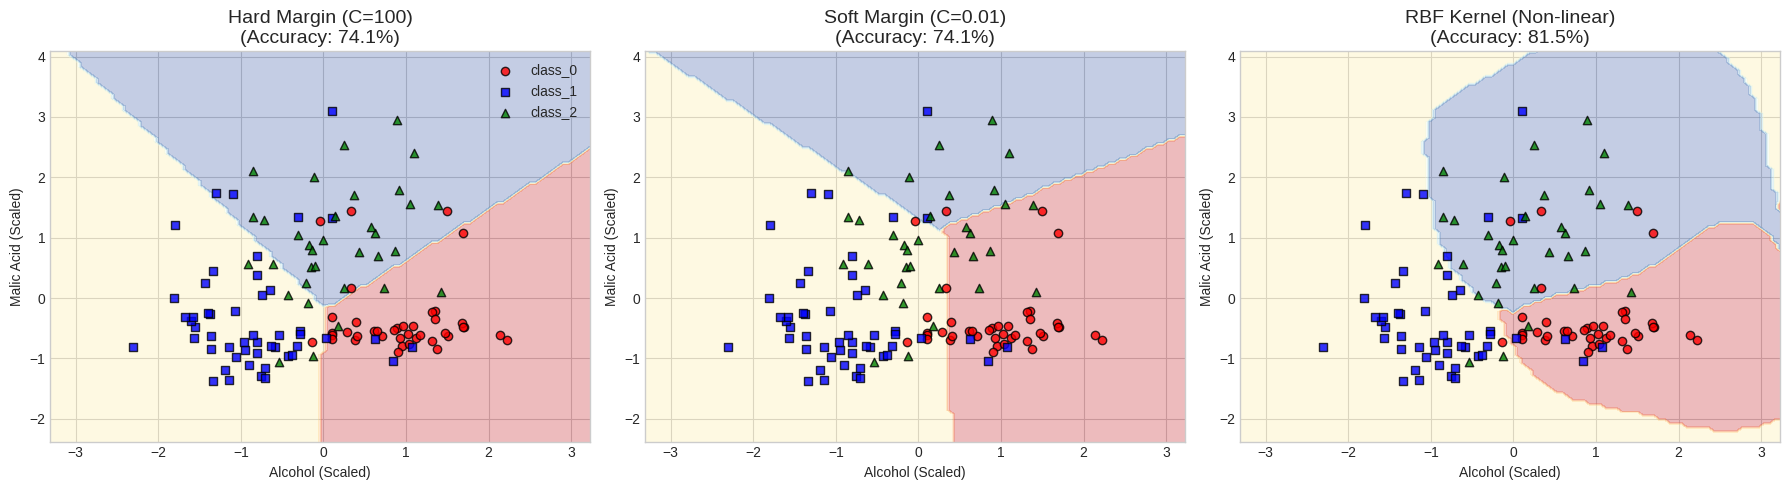

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

plt.style.use('seaborn-v0_8-whitegrid')

# 1. 데이터 로드 및 2차원 특성 추출 (
wine = load_wine()
X_2d = wine.data[:, :2]
y = wine.target

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42)

# 3. 전처리 (스케일링)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 훈련 데이터는 fit과 transform을 동시에
X_test_scaled = scaler.transform(X_test)        # 테스트 데이터는 transform만 적용

# 4. 3가지 SVM 모델 정의
models = {
    "Hard Margin (C=100)": SVC(kernel='linear', C=100),
    "Soft Margin (C=0.01)": SVC(kernel='linear', C=0.01),
    "RBF Kernel (Non-linear)": SVC(kernel='rbf', C=1.0, gamma='scale')
}

# 5. 모델 학습
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

# ==========================================
# 시각화 코드
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

print("=== 와인 분류 모델 성능 평가 ===")

# 학습된 모델들을 하나씩 꺼내어 평가 및 시각화 진행
for ax, (name, model) in zip(axes, models.items()):

    # 예측 및 테스트 데이터 정확도 평가
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"✔️ {name:25} Accuracy: {acc * 100:.2f}%")

    # 결정 경계 시각화
    DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="predict",
        cmap=plt.cm.RdYlBu, alpha=0.3, ax=ax
    )

    # 훈련 데이터 산점도 그리기
    for i, color, marker, target_name in zip(range(3), colors, markers, wine.target_names):
        ax.scatter(X_train_scaled[y_train == i, 0], X_train_scaled[y_train == i, 1],
                   color=color, marker=marker, edgecolors='k', label=target_name, alpha=0.8)

    ax.set_title(f"{name}\n(Accuracy: {acc * 100:.1f}%)", fontsize=14)
    ax.set_xlabel("Alcohol (Scaled)")
    ax.set_ylabel("Malic Acid (Scaled)")

axes[0].legend(loc='best')
plt.tight_layout()
plt.show()